# How to Train Neural Networks with JAX and Flax

I'm learning how to train NNs. To avoid merge conflicts, don't edit this file please. Feel free to read the code if it's useful for you <3

I'll remove the file once we finish the project.

In [ ]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap

# 1. The Random Key (The source of all randomness)
seed = 0
key = jax.random.key(seed)
key, subkey = jax.random.split(key, num=2)

# 2. Generate Synthetic Data (Linear Regression: y = 2x + 1)
# We use standard numpy for data generation, JAX for training
X = jax.random.uniform(subkey, (100, 1))
key, subkey = jax.random.split(key, num=2)
y_true = 2 * X + 0.5 + 0.1 * jax.random.normal(subkey, (100, 1))

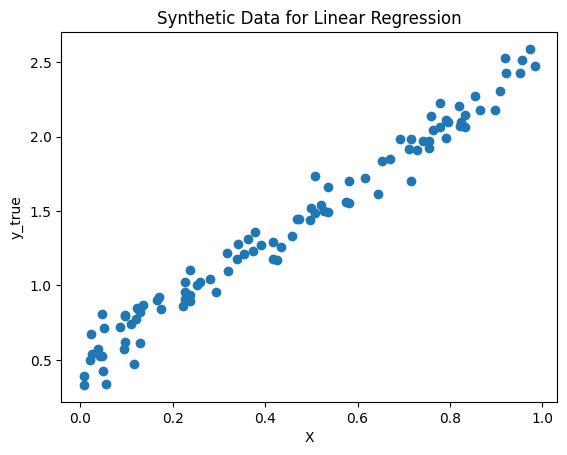

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X, y_true, label="Data")
plt.xlabel("X")
plt.ylabel("y_true")
plt.title("Synthetic Data for Linear Regression")
plt.show()

## 3. Defining the Model with Flax

Unlike PyTorch, where models hold their own state (weights), in JAX/Flax, the model definition is stateless. The parameters are stored separately and passed to the model explicitly.

We'll use `flax.linen` to define our Linear Regression model.


In [ ]:
from flax import linen as nn
import optax


class LinearModel(nn.Module):
    @nn.compact
    def __call__(self, x):
        # Dense corresponds to a Linear layer in PyTorch
        return nn.Dense(features=1)(x)


model = LinearModel()

## 4. Initialization and Optimizer

In JAX, you must use a RNG key to initialize parameters. The optimizer is also purely functional; it returns an `opt_state` that tracks things like momentum, and `optimizer.update` computes the transformations to the gradients.


In [ ]:
# Initialize parameters (Key difference from PyTorch: Explicit PRNG key)
key, subkey = jax.random.split(key)
params = model.init(subkey, X)["params"]  # Returns a frozen dict

print("Parameters:", params)

# Define Optimizer (Optax)
optimizer = optax.adam(learning_rate=0.1)
opt_state = optimizer.init(params)

Parameters: {'Dense_0': {'kernel': Array([[1.2014109]], dtype=float32), 'bias': Array([0.], dtype=float32)}}


## 5. The Training Step

This is where the paradigm shift is most obvious.
1. We define a loss function that takes **parameters** as input.
2. We use `jax.value_and_grad` to get both loss and gradients.
3. We update the parameters and optimizer state explicitly.
4. We JIT compile the whole step for performance.


In [ ]:
@jit
def train_step(params, opt_state, x, y):
    def loss_fn(params):
        # Apply the model using the explicitly passed parameters
        pred = model.apply({"params": params}, x)
        loss = jnp.mean((pred - y) ** 2)
        return loss

    # Compute gradients
    loss_val, grads = jax.value_and_grad(loss_fn)(params)

    # Compute updates and new optimizer state
    updates, opt_state = optimizer.update(grads, opt_state)

    # Apply updates to parameters
    params = optax.apply_updates(params, updates)

    return params, opt_state, loss_val

Epoch 0, Loss: 0.0094
Epoch 10, Loss: 0.0094
Epoch 20, Loss: 0.0094
Epoch 30, Loss: 0.0094
Epoch 40, Loss: 0.0094
Epoch 50, Loss: 0.0094
Epoch 60, Loss: 0.0094
Epoch 70, Loss: 0.0094
Epoch 80, Loss: 0.0094
Epoch 90, Loss: 0.0094
Epoch 100, Loss: 0.0094


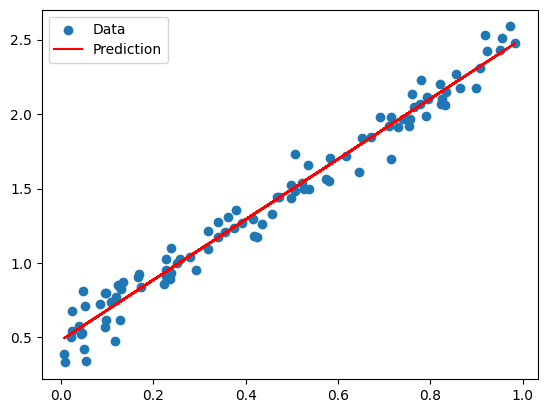

In [ ]:
# Training Loop
for epoch in range(101):
    params, opt_state, loss_val = train_step(params, opt_state, X, y_true)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss_val:.4f}")

# Final visualization
pred = model.apply({"params": params}, X)

plt.scatter(X, y_true, label="Data")
plt.plot(X, pred, color="red", label="Prediction")
plt.legend()
plt.show()

In [ ]:
print("Final Parameters:", params)

Final Parameters: {'Dense_0': {'bias': Array([0.47796384], dtype=float32), 'kernel': Array([[2.0257802]], dtype=float32)}}
